# Projet Airbnb - prédiction du logarithme du prix

Objectif : prédire log_price, c'est-à-dire le logarithme du prix d'un logement Airbnb.

Le projet est organisé en deux parties : exploration qualitative des données, puis préparation des variables et comparaison de plusieurs modèles

## 1. Chargement des bibliothèques et des données

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [120]:
train = pd.read_csv('data/airbnb_train.csv')
test = pd.read_csv('data/airbnb_test.csv')

print('Dimensions train :', train.shape)
print('Dimensions test  :', test.shape)

display(train.head())

Dimensions train : (22234, 28)
Dimensions test  : (51877, 27)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


## 2. Analyse de la base

On regarde les colonnes disponibles et la variable à prédire.

In [113]:
print('Colonnes du train :')
print(list(train.columns))

print()
print('Description de log_price :')
display(train['log_price'].describe())

Colonnes du train :
['id', 'log_price', 'property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'latitude', 'longitude', 'name', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms', 'beds']

Description de log_price :


count    22234.000000
mean         4.783481
std          0.718758
min          2.302585
25%          4.317488
50%          4.700480
75%          5.220356
max          7.600402
Name: log_price, dtype: float64

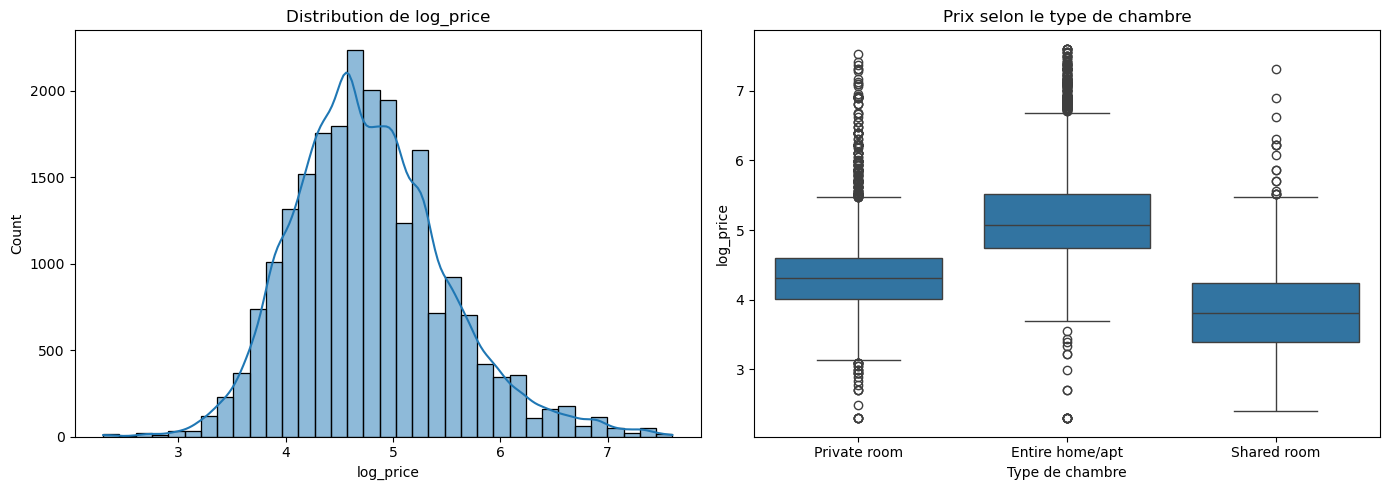

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['log_price'], bins=35, kde=True, ax=axes[0])
axes[0].set_title('Distribution de log_price')
axes[0].set_xlabel('log_price')

sns.boxplot(data=train, x='room_type', y='log_price', ax=axes[1])
axes[1].set_title('Prix selon le type de chambre')
axes[1].set_xlabel('Type de chambre')
axes[1].set_ylabel('log_price')

plt.tight_layout()
plt.show()

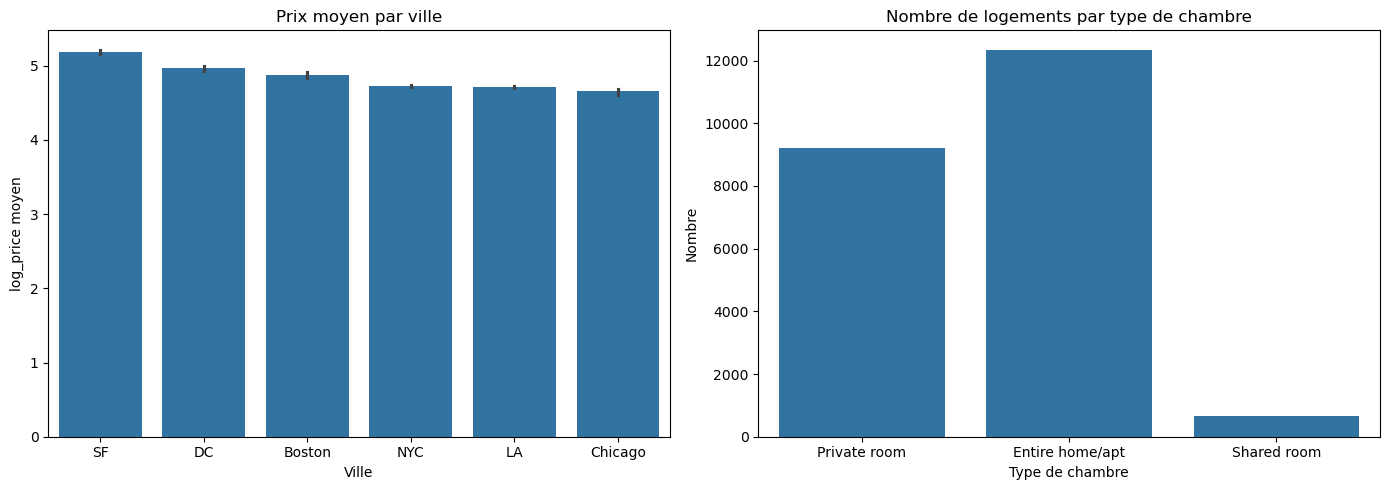

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

city_order = train.groupby('city')['log_price'].mean().sort_values(ascending=False).index
sns.barplot(data=train, x='city', y='log_price', order=city_order, ax=axes[0])
axes[0].set_title('Prix moyen par ville')
axes[0].set_xlabel('Ville')
axes[0].set_ylabel('log_price moyen')

sns.countplot(data=train, x='room_type', ax=axes[1])
axes[1].set_title('Nombre de logements par type de chambre')
axes[1].set_xlabel('Type de chambre')
axes[1].set_ylabel('Nombre')

plt.tight_layout()
plt.show()

## 3. Nettoyage et création de variables

Les algorithmes ont besoin de nombres. On transforme donc les informations textuelles en variables numériques simples.

Exemples : has_kitchen, has_wireless_internet, type, etc.

Les colonnes issues de amenities sont maintenant créées automatiquement avec le format has_[nom_equipement].

In [ ]:
def extract_amenities(text):
    # Cette fonction la transforme en vraie liste Python simple
    text = str(text).strip().strip('{}')
    if text == '':
        return []

    amenities = []
    current = ''
    in_quotes = False

    for char in text:
        if char == '"':
            in_quotes = not in_quotes
        elif char == ',' and not in_quotes:
            amenities.append(current.strip().strip('"'))
            current = ''
        else:
            current += char

    if current.strip() != '':
        amenities.append(current.strip().strip('"'))

    return [amenity for amenity in amenities if amenity != '']


def to_snake_case(text):
    return "_".join(text.lower().split(" "))

def get_amenity_names(df):
    # Récupere automatiquement tous les equipements vus dans le train
    all_amenities = set()
    for text in df['amenities'].fillna(''):
        for amenity in extract_amenities(text):
            all_amenities.add(amenity)
    return sorted(all_amenities)


def get_amenity_columns(amenity_names):
    columns = []
    for amenity in amenity_names:
        column = 'has_' + to_snake_case(amenity)
        if column != 'has_' and column not in columns:
            columns.append(column)
    return columns


def prepare_base(df, amenity_names=None):
    data = df.copy()

    # Regroupement du type de logement
    data['type'] = data['property_type'].replace({
        'Apartment': 'apartment',
        'House': 'house',
        'Condominium': 'condo',
        'Townhouse': 'house',
        'Loft': 'apartment'
    })
    data.loc[~data['type'].isin(['apartment', 'house', 'condo']), 'type'] = 'other'

    # Création automatique des colonnes amenity
    if amenity_names is None:
        amenity_names = get_amenity_names(data)

    amenity_sets = data['amenities'].fillna('').apply(lambda x: set(extract_amenities(x)))
    amenity_data = {}
    for amenity in amenity_names:
        column = 'has_' + to_snake_case(amenity)
        if column != 'has_' and column not in amenity_data:
            amenity_data[column] = amenity_sets.apply(lambda values: int(amenity in values))

    amenity_df = pd.DataFrame(amenity_data, index=data.index)
    data = pd.concat([data, amenity_df], axis=1)
    data.attrs['amenity_columns'] = list(amenity_df.columns)
    data['amenities_count'] = amenity_sets.apply(len)

    # Conversion des booleens en 0/1
    data['cleaning_fee'] = data['cleaning_fee'].astype(int)
    for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
        data[col] = data[col].map({'t': 1, 'f': 0}).fillna(0).astype(int)

    # Pourcentage de reponse du proprio : '100%' devient 100
    data['host_response_rate'] = data['host_response_rate'].astype(str).str.replace('%', '', regex=False)
    data['host_response_rate'] = pd.to_numeric(data['host_response_rate'], errors='coerce')

    # Variables de dates. On prend une date de reference proche de la fin des données
    ref_date = pd.to_datetime('2017-10-01')
    data['host_since'] = pd.to_datetime(data['host_since'], errors='coerce')
    data['first_review'] = pd.to_datetime(data['first_review'], errors='coerce')
    data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

    data['host_days'] = (ref_date - data['host_since']).dt.days
    data['days_since_first_review'] = (ref_date - data['first_review']).dt.days
    data['days_since_last_review'] = (ref_date - data['last_review']).dt.days

    # Variables textes, on garde juste la longueur
    data['description_length'] = data['description'].fillna('').astype(str).str.len()
    data['name_length'] = data['name'].fillna('').astype(str).str.len()

    return data

In [91]:
train_prepared = prepare_base(train)
amenity_feature_cols = train_prepared.attrs['amenity_columns']

created_columns = ['type', 'has_kitchen', 'has_wireless_internet', 'has_air_conditioning',
                   'has_tv', 'amenities_count', 'host_response_rate', 'host_days']

display(train_prepared[created_columns].head())

,type,has_kitchen,has_wireless_internet,has_air_conditioning,has_tv,amenities_count,host_response_rate,host_days
0,house,1,1,0,1,15,NaN,659.0
1,house,1,1,1,0,25,100.0,331.0
2,apartment,1,1,1,1,20,NaN,294.0
3,house,1,1,1,1,30,100.0,1884.0
4,house,1,1,0,1,24,100.0,1529.0


## 4. Corrélations

Repérage des variables numériques les plus liées à log_price. Ici on prend un échantillon représentatif

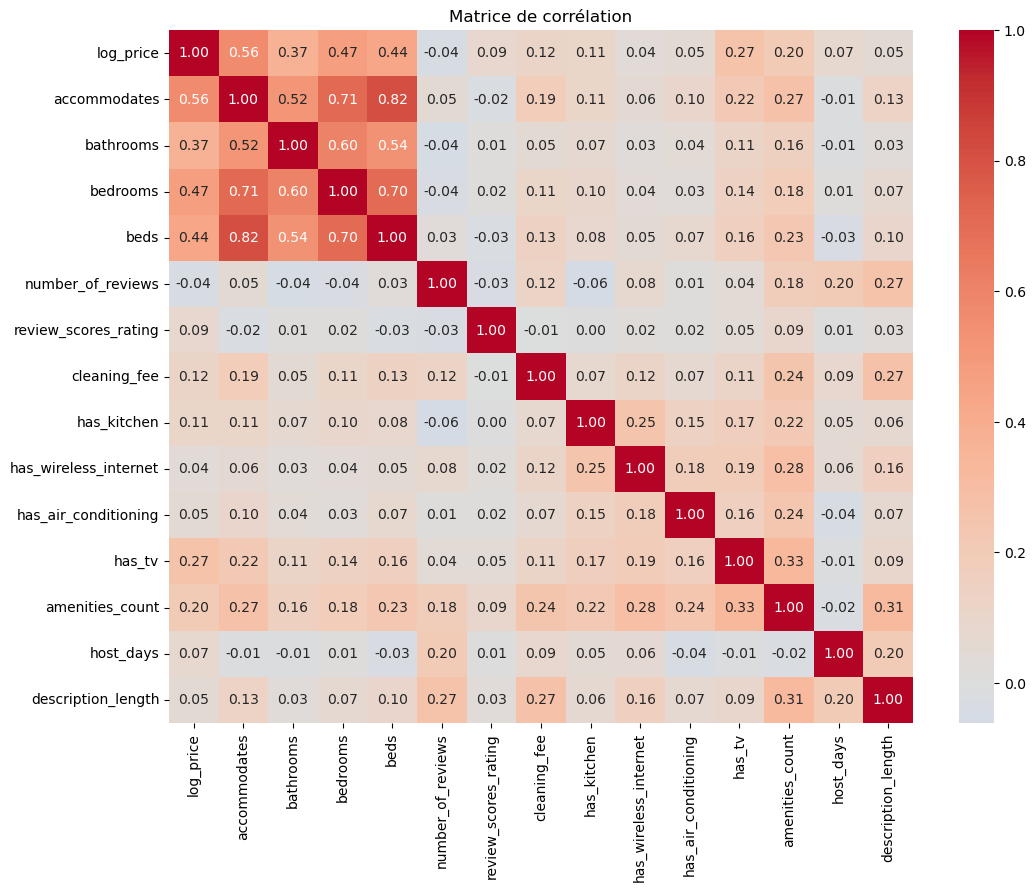

In [90]:
corr_columns = [
    'log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'number_of_reviews', 'review_scores_rating', 'cleaning_fee',
    'has_kitchen', 'has_wireless_internet', 'has_air_conditioning', 'has_tv',
    'amenities_count', 'host_days', 'description_length'
]

corr_data = train_prepared[corr_columns].copy()
corr_data = corr_data.fillna(corr_data.median(numeric_only=True))

plt.figure(figsize=(12, 9))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

## 5. Préparation des variables pour les modèles

On sépare les variables numériques et de catégorie.

Les valeurs manquantes numériques sont remplacées par la médiane calculée sur l'ensemble d'entraînement.

In [104]:
base_numeric_cols = [
    'accommodates', 'bathrooms', 'latitude', 'longitude', 'number_of_reviews',
    'review_scores_rating', 'bedrooms', 'beds', 'host_response_rate',
    'host_days', 'days_since_first_review', 'days_since_last_review',
    'description_length', 'name_length', 'amenities_count',
    'cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable'
]

category_cols = ['city', 'room_type', 'bed_type', 'cancellation_policy', 'type']


def make_features(train_df, other_df=None):
    # Les colonnes amenities sont apprises sur le train puis appliquees ailleurs.
    amenity_names = get_amenity_names(train_df)
    amenity_cols = get_amenity_columns(amenity_names)
    numeric_cols = base_numeric_cols + amenity_cols

    base_train = prepare_base(train_df, amenity_names)

    if other_df is None:
        all_data = base_train
    else:
        base_other = prepare_base(other_df, amenity_names)
        all_data = pd.concat([base_train, base_other], axis=0, ignore_index=True)

    medians = base_train[numeric_cols].median(numeric_only=True)
    all_num = all_data[numeric_cols].fillna(medians).fillna(0)

    all_cat = pd.get_dummies(all_data[category_cols].fillna('missing'), drop_first=False)
    all_features = pd.concat([all_num.reset_index(drop=True), all_cat.reset_index(drop=True)], axis=1)

    X_train = all_features.iloc[:len(base_train)].copy()
    if other_df is None:
        return X_train

    X_other = all_features.iloc[len(base_train):].copy()
    return X_train, X_other

In [105]:
train_part, validation_part = train_test_split(train, test_size=0.2, random_state=0)

X_train, X_validation = make_features(train_part, validation_part)
y_train = train_part['log_price']
y_validation = validation_part['log_price']

display(X_train.head())

,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,host_response_rate,host_days,...,bed_type_Real Bed,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict,cancellation_policy_super_strict_30,cancellation_policy_super_strict_60,type_apartment,type_condo,type_house,type_other
0,4,1.0,40.805670,-73.941297,4,100.0,1.0,1.0,100.0,418.0,...,True,False,True,False,False,False,True,False,False,False
1,8,4.0,33.982285,-118.468014,12,100.0,4.0,4.0,100.0,2048.0,...,True,False,False,True,False,False,False,False,True,False
2,3,1.0,40.722003,-73.981017,7,87.0,1.0,1.0,100.0,1384.0,...,True,False,True,False,False,False,True,False,False,False
3,2,1.0,42.008025,-87.672539,65,99.0,1.0,1.0,100.0,1606.0,...,True,False,True,False,False,False,True,False,False,False
4,2,1.0,41.828882,-87.620180,14,99.0,1.0,1.0,100.0,1600.0,...,True,False,True,False,False,False,False,True,False,False


## 6. Modèles testés

On compare plusieurs approches :

- régression linéaire
- descente de gradient
- ACP puis régression linéaire
- arbres de décision avec plusieurs profondeurs

In [108]:
results = []
validation_predictions = {}

def add_result(name, prediction):
    mse = mean_squared_error(y_validation, prediction)
    results.append({
        'modele': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_validation, prediction),
        'R2': r2_score(y_validation, prediction)
    })
    validation_predictions[name] = prediction
    
# Régression linéaire
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
add_result('Régression linéaire', linear_model.predict(X_validation))

# Descente de gradient
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

sgd_model = SGDRegressor(max_iter=5000, tol=0.0001, eta0=0.0001,
                         learning_rate='constant', random_state=0)
sgd_model.fit(X_train_scaled, y_train)
add_result('Descente de gradient', sgd_model.predict(X_validation_scaled))

# ACP + régression linéaire
for n_components in [5, 10, 20]:
    pca = PCA(n_components=n_components, random_state=0)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_validation_pca = pca.transform(X_validation_scaled)

    pca_model = LinearRegression()
    pca_model.fit(X_train_pca, y_train)
    add_result('ACP ' + str(n_components) + ' + régression', pca_model.predict(X_validation_pca))

# Arbres de décision
for depth in [4, 6, 8, 10, 12, 14]:
    tree_model = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=20, random_state=0)
    tree_model.fit(X_train, y_train)
    add_result('Arbre profondeur ' + str(depth), tree_model.predict(X_validation))

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(results_df)

,modele,MSE,RMSE,MAE,R2
0,Arbre profondeur 10,0.201683,0.449091,0.324770,0.610078
1,Arbre profondeur 12,0.202373,0.449859,0.325596,0.608742
2,Arbre profondeur 14,0.203856,0.451504,0.328104,0.605876
3,Arbre profondeur 8,0.204398,0.452104,0.328675,0.604829
4,Régression linéaire,0.210279,0.458562,0.338713,0.593459
5,Descente de gradient,0.219679,0.468699,0.348218,0.575285
6,Arbre profondeur 6,0.223833,0.473110,0.349109,0.567254
7,Arbre profondeur 4,0.246239,0.496225,0.372190,0.523935
8,ACP 20 + régression,0.273274,0.522756,0.386343,0.471667
9,ACP 10 + régression,0.300848,0.548496,0.412962,0.418357


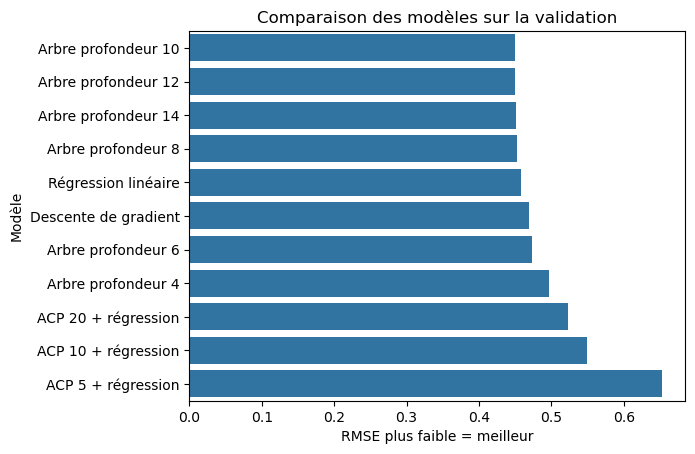

In [110]:
sns.barplot(data=results_df, y='modele', x='RMSE')
plt.title('Comparaison des modèles sur la validation')
plt.xlabel('RMSE plus faible = meilleur')
plt.ylabel('Modèle')
plt.show()

## 7. Analyse du meilleur modèle

Le meilleur modèle est choisi avec la RMSE de validation, car on veut limiter l'erreur moyenne de prédiction sur log_price.

Meilleur modèle : Arbre profondeur 10
RMSE : 0.4491
MAE : 0.3248
R2 : 0.6101


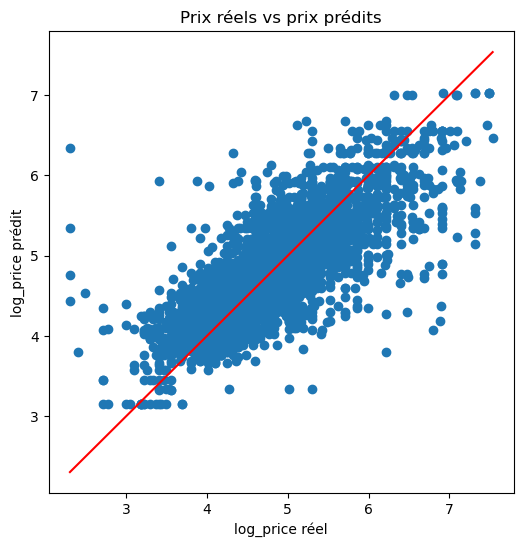

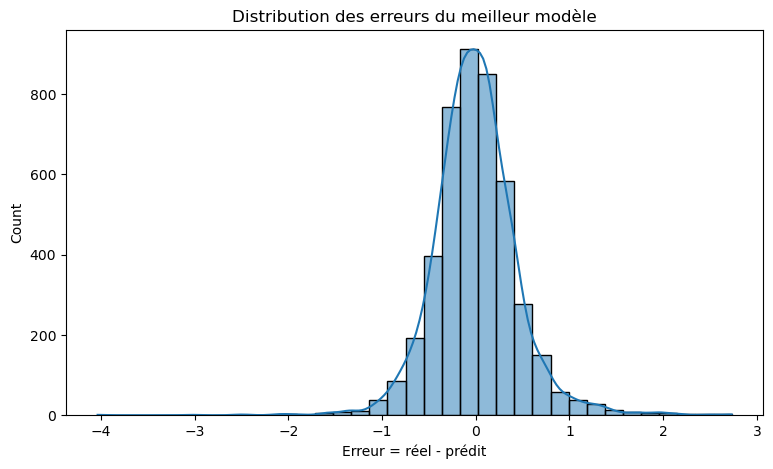

In [111]:
best_name = results_df.loc[0, 'modele']
best_prediction = validation_predictions[best_name]

print('Meilleur modèle :', best_name)
print('RMSE :', round(results_df.loc[0, 'RMSE'], 4))
print('MAE :', round(results_df.loc[0, 'MAE'], 4))
print('R2 :', round(results_df.loc[0, 'R2'], 4))

plt.figure(figsize=(6, 6))
plt.scatter(y_validation, best_prediction)
plt.plot([y_validation.min(), y_validation.max()],
         [y_validation.min(), y_validation.max()], color='red')

plt.title('Prix réels vs prix prédits')
plt.xlabel('log_price réel')
plt.ylabel('log_price prédit')
plt.show()

residuals = y_validation - best_prediction
plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=35, kde=True)
plt.title('Distribution des erreurs du meilleur modèle')
plt.xlabel('Erreur = réel - prédit')
plt.show()

,variable,importance
147,room_type_Entire home/apt,0.517718
1,bathrooms,0.170664
3,longitude,0.090950
2,latitude,0.069571
0,accommodates,0.030251
6,bedrooms,0.026170
4,number_of_reviews,0.024018
149,room_type_Shared room,0.008165
143,city_DC,0.006016
53,has_elevator,0.005646


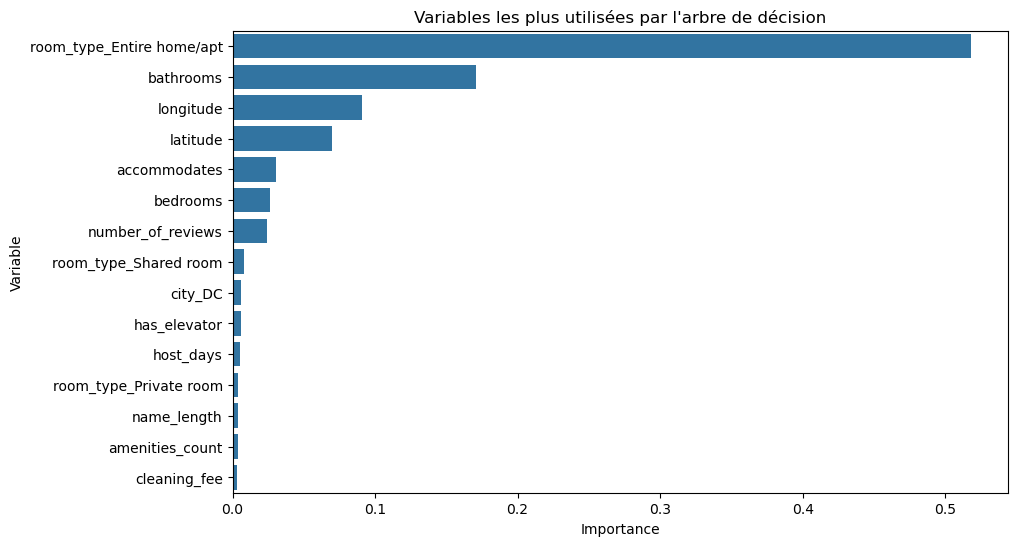

In [83]:
# On réentraîne l'arbre choisi pour afficher les variables les plus importantes.
best_tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=0)
best_tree.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'variable': X_train.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False).head(15)

display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y='variable', x='importance')
plt.title("Variables les plus utilisées par l'arbre de décision")
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.show()

## 8. Entraînement final et fichier de prédiction

On entraîne le meilleur modèle sur tout le fichier airbnb_train.csv, puis on prédit les lignes de airbnb_test.csv.

In [85]:
X_full_train, X_test = make_features(train, test)
y_full_train = train['log_price']

final_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=0)
final_model.fit(X_full_train, y_full_train)

test_predictions = final_model.predict(X_test)

predictions = pd.DataFrame({
    '': test['Unnamed: 0'],
    'logpred': test_predictions
})

predictions.to_csv('predictions.csv', index=False)

display(predictions.head())

,,logpred
0,14282777,4.859864
1,17029381,5.967880
2,7824740,5.076205
3,19811650,6.189647
4,12410741,4.604836


## Conclusion

Le nettoyage des données a permis de transformer des colonnes textuelles en variables numériques simples : type de logement regroupé, présence des équipements, longueurs de textes, etc.

Pour le test des modèles, la baseline est utile pour vérifier que les modèles apprennent réellement quelque chose. La régression linéaire donne déjà un résultat correct, mais l'arbre de décision de profondeur limitée obtient le meilleur score sur la validation. Il est donc choisi pour produire le fichier final predictions.csv.

Les variables les plus importantes sont cohérentes avec le problème : capacité d'accueil, type de chambre, nombre de chambres, localisation et équipements.